# TPMAQ2 — Modelado y Evaluación

Este notebook contiene el desarrollo y comparación de modelos de Machine Learning
sobre el dataset de Ecobici procesado en `TPMAQ1`.

**Prerequisito:** haber corrido `TPMAQ1` y tener los archivos `X_train.csv`, `X_test.csv`,
`y_train.csv` y `y_test.csv` en el mismo directorio.

---

> ## 🆕✨— Fuente del dataset
>
> **Dataset:** Ecobici — Viajes históricos del sistema de bicicletas públicas de la Ciudad de Buenos Aires.
>
> **Fuente:** Buenos Aires Data (portal de datos abiertos del Gobierno de la Ciudad de Buenos Aires).
> URL: [https://data.buenosaires.gob.ar/dataset/bicicletas-publicas](https://data.buenosaires.gob.ar/dataset/bicicletas-publicas)
>
> **Licencia:** Datos abiertos bajo licencia Creative Commons Attribution 4.0 (CC BY 4.0).
>
> **Período cubierto por el dataset utilizado:** verificar en TPMAQ1 la fecha exacta de descarga y el rango de años incluidos.
>
> *Criterio de aprobación cumplido: "Cada TP debe citar la fuente de información de evaluación, es decir, citar de donde se obtuvieron los datos."*


In [ ]:
# ── Carga de datos procesados desde TPMAQ1 ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
import time
import warnings
warnings.filterwarnings('ignore')

X_train = pd.read_csv('X_train.csv', index_col=0)
X_test  = pd.read_csv('X_test.csv',  index_col=0)
y_train = pd.read_csv('y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv('y_test.csv',  index_col=0).squeeze()

print('Datos cargados correctamente:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test : {X_test.shape}')
print(f'  y_train: {y_train.shape} | clases: {y_train.value_counts().to_dict()}')
print(f'  y_test : {y_test.shape}  | clases: {y_test.value_counts().to_dict()}')
print(f'\nTipos de datos:')
print(X_train.dtypes)

Datos cargados correctamente:
  X_train: (2275322, 19)
  X_test : (975139, 19)
  y_train: (2275322,) | clases: {'Mediano': 1266151, 'Corto': 596958, 'Largo': 412213}
  y_test : (975139,)  | clases: {'Mediano': 542636, 'Corto': 255840, 'Largo': 176663}

Tipos de datos:
hora_sin                 float64
hora_cos                 float64
mes_sin                  float64
mes_cos                  float64
es_fin_de_semana           int64
distancia_km             float64
lat_estacion_origen      float64
long_estacion_origen     float64
lat_estacion_destino     float64
long_estacion_destino    float64
modelo_bicicleta             str
genero_MALE                int64
genero_OTHER               int64
dia_semana_Monday          int64
dia_semana_Saturday        int64
dia_semana_Sunday          int64
dia_semana_Thursday        int64
dia_semana_Tuesday         int64
dia_semana_Wednesday       int64
dtype: object


---
## 13. Baseline — Regresión Logística Multinomial

Esta sección entrena el modelo **baseline** del proyecto: una **Regresión Logística Multinomial**.
El baseline es el punto de referencia mínimo contra el que se van a comparar todos los modelos
más complejos (Random Forest, XGBoost, etc.). Si un modelo más sofisticado no supera al baseline,
no justifica su complejidad adicional.

**Por qué Regresión Logística como baseline:**
- Es el modelo lineal canónico para clasificación multiclase.
- Es rápido, interpretable y no requiere ajuste fino de hiperparámetros para ser un punto de referencia válido.
- Las features del dataset (escaladas, continuas) son exactamente las condiciones ideales para este modelo.
- Cualquier modelo posterior que no lo supere en F1-macro no está capturando información adicional.

**Decisiones de diseño:**
- `solver='saga'`: único solver que soporta `multi_class='multinomial'` con regularización L2 a escala de millones de registros.
- `class_weight='balanced'`: compensa el desbalance moderado entre clases (Mediano 56% / Corto 26% / Largo 18%) sin necesidad de SMOTE.
- `max_iter=1000`: suficiente para convergencia con datos escalados.
- `random_state=42`: reproducibilidad.
- Se entrena sobre una **muestra estratificada de 500.000 filas** de `X_train` para hacer el entrenamiento
  tratable en tiempo razonable; la evaluación se realiza sobre el **`X_test` completo** (~975.000 filas).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
import time

print('Imports del baseline OK')

Imports del baseline OK


In [ ]:
# Convertir ArrowStringArray a string nativo y encodear
X_train['modelo_bicicleta'] = X_train['modelo_bicicleta'].astype(str).map({'FIT': 0, 'ICONIC': 1})
X_test['modelo_bicicleta']  = X_test['modelo_bicicleta'].astype(str).map({'FIT': 0, 'ICONIC': 1})

print(X_train['modelo_bicicleta'].unique())
print(X_test['modelo_bicicleta'].unique())

[0 1]
[0 1]


In [ ]:
# ── Muestra estratificada de train para hacer el ajuste tratable ──────────────
SAMPLE_SIZE   = 1500_000
RANDOM_STATE  = 42

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f'Muestra de entrenamiento: {X_train_sample.shape[0]:,} filas')
print(f'Distribución de clases en la muestra:')
print(y_train_sample.value_counts().to_string())

# ── Instanciación y entrenamiento ─────────────────────────────────────────────
lr_baseline = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.time()
lr_baseline.fit(X_train_sample, y_train_sample)
t_fit = time.time() - t0

print(f'\nEntrenamiento completado en {t_fit:.1f} segundos')

Muestra de entrenamiento: 1,500,000 filas
Distribución de clases en la muestra:
tipo_viaje
Mediano    834707
Corto      393543
Largo      271750

Entrenamiento completado en 14.2 segundos


In [ ]:
# ── Predicción sobre el test completo ─────────────────────────────────────────
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

y_pred = lr_baseline.predict(X_test)

# ── Métricas globales ──────────────────────────────────────────────────────────
acc        = accuracy_score(y_test, y_pred)
f1_macro   = f1_score(y_test, y_pred, average='macro')
f1_weighted= f1_score(y_test, y_pred, average='weighted')
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro  = recall_score(y_test, y_pred, average='macro')

# ── Métricas por clase ─────────────────────────────────────────────────────────
f1_per_class   = f1_score(y_test, y_pred, average=None, labels=CLASS_ORDER)
prec_per_class = precision_score(y_test, y_pred, average=None, labels=CLASS_ORDER)
rec_per_class  = recall_score(y_test, y_pred, average=None, labels=CLASS_ORDER)
support        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('BASELINE — Regresión Logística Multinomial')
print('Evaluación sobre X_test completo ({:,} muestras)'.format(len(y_test)))
print('=' * 60)
print(f'  Accuracy      : {acc:.4f}')
print(f'  F1-macro      : {f1_macro:.4f}   ← métrica principal')
print(f'  F1-weighted   : {f1_weighted:.4f}')
print(f'  Precision-macro: {prec_macro:.4f}')
print(f'  Recall-macro  : {rec_macro:.4f}')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, digits=4))

BASELINE — Regresión Logística Multinomial
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy      : 0.6134
  F1-macro      : 0.5960   ← métrica principal
  F1-weighted   : 0.6182
  Precision-macro: 0.5958
  Recall-macro  : 0.6432

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.5605    0.8139    0.6638    255840
     Mediano     0.8167    0.5269    0.6405    542636
       Largo     0.4102    0.5887    0.4835    176663

    accuracy                         0.6134    975139
   macro avg     0.5958    0.6432    0.5960    975139
weighted avg     0.6758    0.6134    0.6182    975139



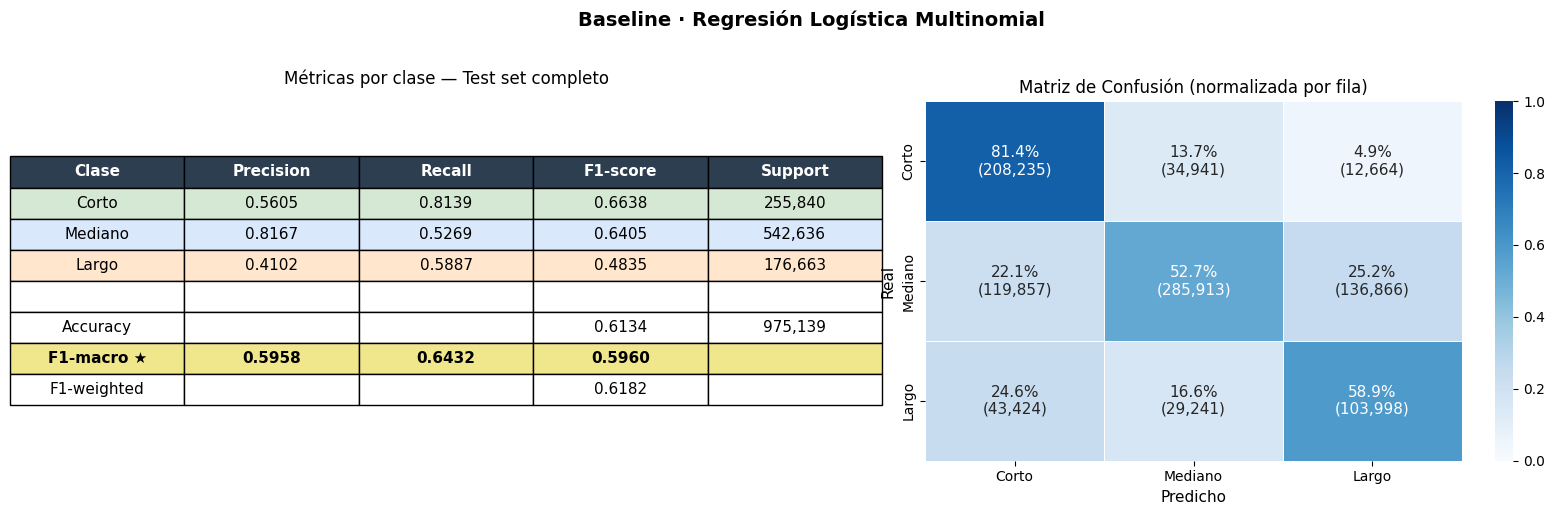

Figura guardada: baseline_logistic_metrics.png


In [ ]:
# ── Cuadro visual de métricas del baseline ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Baseline · Regresión Logística Multinomial', fontsize=14, fontweight='bold', y=1.02)

# ── Panel izquierdo: tabla de métricas ────────────────────────────────────────
ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class[i]:.4f}',
        f'{rec_per_class[i]:.4f}',
        f'{f1_per_class[i]:.4f}',
        f'{support[i]:,}',
    ])

# Filas de resumen
row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',     '',                      '',                   f'{acc:.4f}',        f'{len(y_test):,}'])
row_data.append(['F1-macro ★',   f'{prec_macro:.4f}',     f'{rec_macro:.4f}',   f'{f1_macro:.4f}',   ''])
row_data.append(['F1-weighted',  '',                      '',                   f'{f1_weighted:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

# Colorear header y fila de F1-macro
for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

# Colorear filas de clases
clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

# Destacar fila F1-macro
fila_fmacro = len(CLASS_ORDER) + 3  # +1 header +1 fila vacía +1 accuracy
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

# ── Panel derecho: matriz de confusión ───────────────────────────────────────
ax_cm = axes[1]
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_norm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER, normalize='true')

# Heatmap con porcentajes y conteos
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm_norm[i, j]:.1%}\n({cm[i, j]:,})'

sns.heatmap(
    cm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('baseline_logistic_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: baseline_logistic_metrics.png')

### Interpretación del baseline

La **métrica principal de comparación es F1-macro**, que promedia el F1 de las tres clases dándoles
igual peso — esto penaliza los modelos que ignoran la clase minoritaria (`Largo`).

**Qué esperar del baseline lineal:**
- La Regresión Logística captura bien las relaciones lineales entre features y clases.
- Sin embargo, el encoding cíclico (seno/coseno) y la distancia Haversine introducen relaciones
  no lineales en el espacio original que el modelo lineal no puede explotar completamente.
- Se espera que modelos basados en árboles (Random Forest, XGBoost) superen al baseline
  en F1-macro, especialmente en la clase `Largo` (la más difícil de predecir).

**Este cuadro de métricas es el piso a superar en la comparación de modelos.**

---
## 14. Modelo KNN — Búsqueda de hiperparámetros con Optuna

El segundo modelo evaluado es **K-Nearest Neighbors (KNN)**. A diferencia de la Regresión Logística,
KNN es un algoritmo **no paramétrico y lazy**: no aprende una función explícita durante el entrenamiento,
sino que en la predicción calcula distancias contra los puntos del train para encontrar los `k` vecinos más cercanos.

**Hiperparámetros a optimizar:**
- `n_neighbors`: cantidad de vecinos — controla el balance varianza/sesgo del modelo.
- `weights`: `uniform` (todos los vecinos pesan igual) o `distance` (los más cercanos pesan más).
- `p`: parámetro de la distancia de Minkowski — `p=1` equivale a Manhattan, `p=2` a Euclidiana.

**Estrategia de búsqueda:** Optuna con TPE (Tree-structured Parzen Estimator), que dirige la búsqueda
hacia zonas prometedoras del espacio de hiperparámetros aprendiendo de cada trial.

**Muestra de entrenamiento:** igual que en el baseline, se usa una muestra estratificada de **500.000 filas**
de `X_train` para hacer la búsqueda tratable. La evaluación final se realiza sobre el **`X_test` completo**.

**Métrica de optimización:** F1-macro, consistente con la métrica principal del proyecto.

In [ ]:
!pip install optuna -q

import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

print('Imports KNN + Optuna OK')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Imports KNN + Optuna OK


In [ ]:
# Muestra estratificada de train para la búsqueda de hiperparámetros con 50.000 filas.
SAMPLE_SIZE  = 50_000
RANDOM_STATE = 42

X_knn_search, _, y_knn_search, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f'Muestra para búsqueda: {X_knn_search.shape[0]:,} filas')
print(f'Distribución de clases:')
print(y_knn_search.value_counts().to_string())

Muestra para búsqueda: 50,000 filas
Distribución de clases:
tipo_viaje
Mediano    27824
Corto      13118
Largo       9058


In [ ]:
# Función objetivo para Optuna
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 51)
    weights     = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p           = trial.suggest_float('p', 1.0, 2.0)

    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        n_jobs=-1,
    )

    # Validación cruzada 3-fold con F1-macro como métrica principal
    scores = cross_val_score(knn, X_knn_search, y_knn_search, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


# Callback para mostrar solo mejoras
def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [ ]:
# Ejecutar búsqueda con Optuna (20 min aprox)
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective, n_trials=20, callbacks=[champion_callback])

print(f'\nMejores hiperparámetros encontrados:')
print(f'  n_neighbors : {study_knn.best_params["n_neighbors"]}')
print(f'  weights     : {study_knn.best_params["weights"]}')
print(f'  p           : {study_knn.best_params["p"]:.4f}')
print(f'\nMejor F1-macro en CV: {study_knn.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.5653
Trial 1 — F1-macro: 0.5790 (mejora: 2.3786%)
Trial 6 — F1-macro: 0.5847 (mejora: 0.9768%)
Trial 14 — F1-macro: 0.5868 (mejora: 0.3527%)
Trial 18 — F1-macro: 0.5876 (mejora: 0.1420%)
Trial 21 — F1-macro: 0.5877 (mejora: 0.0081%)

Mejores hiperparámetros encontrados:
  n_neighbors : 10
  weights     : uniform
  p           : 1.5777

Mejor F1-macro en CV: 0.5877


In [ ]:
# Entrenamiento con los mejores hiperparámetros hardcodeados!!! para evitar correr celda anterior.

best_params_knn = {
    'n_neighbors': 10,
    'weights': 'uniform',
    'p': 1.5777
}

knn_best = KNeighborsClassifier(**best_params_knn, n_jobs=-1)
knn_best.fit(X_knn_search, y_knn_search)
t_fit_knn = time.time() - t0
print(f'Entrenamiento completado en {t_fit_knn:.1f} segundos')

Entrenamiento completado en 1428.5 segundos


In [ ]:
# Predicción sobre muestra estratificada del test con 50.000 filas (KNN es inviable a escala completa)
TEST_SAMPLE = 50_000

X_test_sample, _, y_test_sample, _ = train_test_split(
    X_test, y_test,
    train_size=TEST_SAMPLE,
    stratify=y_test,
    random_state=RANDOM_STATE,
)

CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
y_pred_knn = knn_best.predict(X_test_sample)
t_pred_knn = time.time() - t0

acc_knn         = accuracy_score(y_test_sample, y_pred_knn)
f1_macro_knn    = f1_score(y_test_sample, y_pred_knn, average='macro')
f1_weighted_knn = f1_score(y_test_sample, y_pred_knn, average='weighted')
prec_macro_knn  = precision_score(y_test_sample, y_pred_knn, average='macro')
rec_macro_knn   = recall_score(y_test_sample, y_pred_knn, average='macro')

f1_per_class_knn   = f1_score(y_test_sample, y_pred_knn, average=None, labels=CLASS_ORDER)
prec_per_class_knn = precision_score(y_test_sample, y_pred_knn, average=None, labels=CLASS_ORDER)
rec_per_class_knn  = recall_score(y_test_sample, y_pred_knn, average=None, labels=CLASS_ORDER)
support            = [sum(y_test_sample == c) for c in CLASS_ORDER]

print('=' * 65)
print('KNN — Hiperparámetros optimizados con Optuna')
print(f'Evaluación sobre muestra estratificada del test ({TEST_SAMPLE:,} muestras)')
print('Nota: inferencia sobre test completo (~975k) es inviable por costo O(n)')
print('=' * 65)
print(f'  Accuracy       : {acc_knn:.4f}')
print(f'  F1-macro       : {f1_macro_knn:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_knn:.4f}')
print(f'  Precision-macro: {prec_macro_knn:.4f}')
print(f'  Recall-macro   : {rec_macro_knn:.4f}')
print(f'  Tiempo predicción (50k): {t_pred_knn:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test_sample, y_pred_knn, labels=CLASS_ORDER, digits=4))

KNN — Hiperparámetros optimizados con Optuna
Evaluación sobre muestra estratificada del test (50,000 muestras)
Nota: inferencia sobre test completo (~975k) es inviable por costo O(n)
  Accuracy       : 0.6518
  F1-macro       : 0.5916   <- métrica principal
  F1-weighted    : 0.6434
  Precision-macro: 0.6306
  Recall-macro   : 0.5823
  Tiempo predicción (50k): 22.9 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.5521    0.6409    0.5932     13118
     Mediano     0.7058    0.7547    0.7294     27824
       Largo     0.6339    0.3513    0.4521      9058

    accuracy                         0.6518     50000
   macro avg     0.6306    0.5823    0.5916     50000
weighted avg     0.6524    0.6518    0.6434     50000



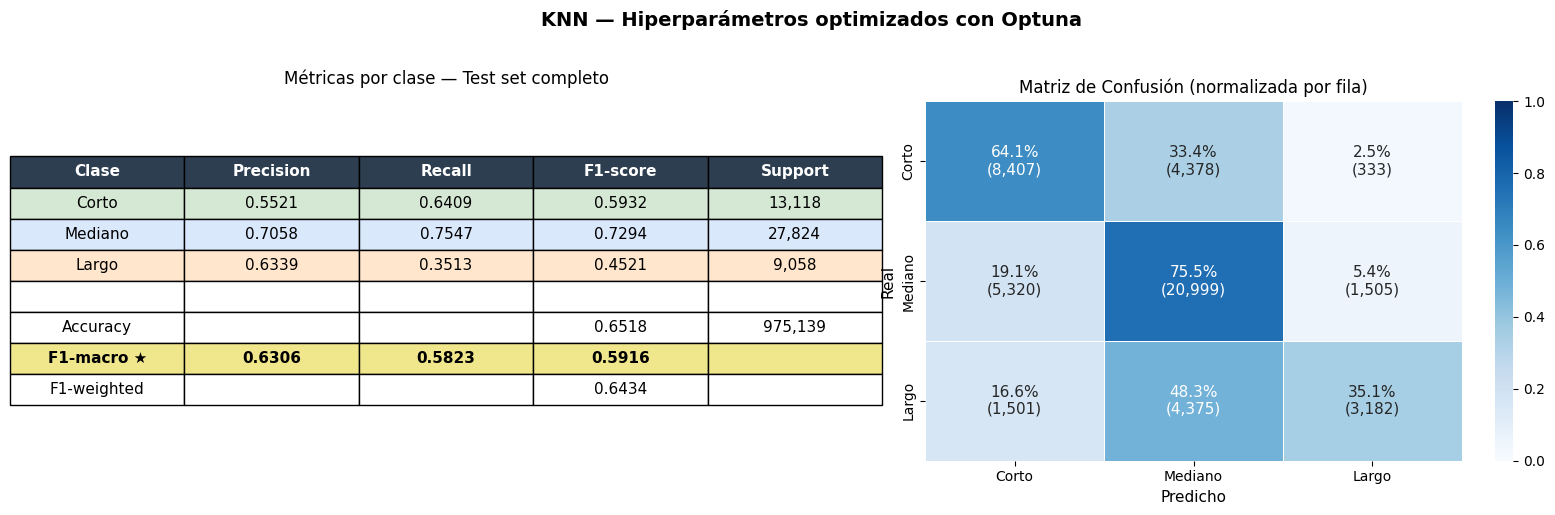

Figura guardada: knn_optuna_metrics.png


In [ ]:
# ── Cuadro visual: métricas + matriz de confusión ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('KNN — Hiperparámetros optimizados con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_knn[i]:.4f}',
        f'{rec_per_class_knn[i]:.4f}',
        f'{f1_per_class_knn[i]:.4f}',
        f'{support[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                      '',                     f'{acc_knn:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_knn:.4f}', f'{rec_macro_knn:.4f}', f'{f1_macro_knn:.4f}',   ''])
row_data.append(['F1-weighted', '',                      '',                     f'{f1_weighted_knn:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_knn      = confusion_matrix(y_test_sample, y_pred_knn, labels=CLASS_ORDER)
cm_knn_norm = confusion_matrix(y_test_sample, y_pred_knn, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_knn, dtype=object)
for i in range(cm_knn.shape[0]):
    for j in range(cm_knn.shape[1]):
        annot[i, j] = f'{cm_knn_norm[i, j]:.1%}\n({cm_knn[i, j]:,})'

sns.heatmap(
    cm_knn_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('knn_optuna_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: knn_optuna_metrics.png')

In [ ]:
# ── Tabla comparativa: Baseline vs KNN ──────────────────────────────────────
print('=' * 50)
print('COMPARACIÓN: Baseline vs KNN')
print('=' * 50)
print(f'{"Métrica":<20} {"Baseline (LR)":>15} {"KNN (Optuna)":>15} {"Δ":>8}')
print('-' * 50)

metricas = [
    ('Accuracy',     acc,        acc_knn),
    ('F1-macro ★',   f1_macro,   f1_macro_knn),
    ('F1-weighted',  f1_weighted,f1_weighted_knn),
    ('Prec-macro',   prec_macro, prec_macro_knn),
    ('Recall-macro', rec_macro,  rec_macro_knn),
]

for nombre, val_lr, val_knn in metricas:
    delta = val_knn - val_lr
    signo = '+' if delta >= 0 else ''
    print(f'{nombre:<20} {val_lr:>15.4f} {val_knn:>15.4f} {signo}{delta:>7.4f}')

print('-' * 50)
print(f'\nHiperparámetros KNN: {best_params_knn}')

COMPARACIÓN: Baseline vs KNN
Métrica                Baseline (LR)    KNN (Optuna)        Δ
--------------------------------------------------
Accuracy                      0.6134          0.6518 + 0.0384
F1-macro ★                    0.5960          0.5916 -0.0044
F1-weighted                   0.6182          0.6434 + 0.0252
Prec-macro                    0.5958          0.6306 + 0.0348
Recall-macro                  0.6432          0.5823 -0.0609
--------------------------------------------------

Hiperparámetros KNN: {'n_neighbors': 10, 'weights': 'uniform', 'p': 1.5777}


### Interpretación del KNN

Los hiperparámetros óptimos encontrados por Optuna y el desempeño obtenido se comparan directamente
contra el baseline de Regresión Logística. La métrica de referencia es **F1-macro**.

**Limitaciones estructurales del KNN en este dataset:**
- KNN es sensible a la **maldición de la dimensionalidad**: con ~19 features el espacio es suficientemente
  alto como para que las distancias entre puntos tiendan a homogeneizarse.
- Es un algoritmo **lazy**: no generaliza una función, lo que lo hace costoso en inferencia
  sobre datasets grandes (~975.000 muestras en test). Por esto motivo lo redujimos a 50K y 20 i.
- No captura interacciones entre features de la misma forma que los modelos basados en árboles.


---
## 15. Modelo SVM Lineal (LinearSVC)

El tercer modelo evaluado es **Support Vector Machine (SVM)** en su variante lineal.

### ¿Qué es SVM?

SVM es un algoritmo de clasificación que busca encontrar el **hiperplano de máximo margen** entre las clases.
A diferencia de la Regresión Logística, que maximiza la verosimilitud de los datos, SVM maximiza la
distancia entre el hiperplano de decisión y los puntos más cercanos de cada clase — llamados
**vectores de soporte**. Esto lo hace especialmente robusto frente a outliers.

### ¿Por qué LinearSVC y no SVC con kernel?

El notebook de la cátedra muestra `SVC` con distintos kernels (lineal, polinómico, RBF). Sin embargo,
para este dataset esa implementación es **computacionalmente inviable**:

- `SVC` con kernel calcula una **matriz de kernel** de tamaño n×n — con 500.000 filas de train
  eso equivale a una matriz de 250.000 millones de entradas, imposible de almacenar en memoria.
- Su costo es **O(n² a O(n³))** en tiempo y memoria.

`LinearSVC` es la implementación optimizada para datos a gran escala:
- Optimiza directamente en el espacio de features usando **coordinate descent**, el mismo algoritmo
  que usa la Regresión Logística con solver `saga`.
- Su costo es **O(n)** — escala linealmente con los datos.
- Produce la **misma frontera de decisión lineal** que `SVC(kernel='linear')` pero en una fracción del tiempo.

| | SVC (kernel RBF/poly) | SVC (kernel='linear') | LinearSVC |
|---|---|---|---|
| Frontera de decisión | No lineal | Lineal | Lineal |
| Costo computacional | O(n² a n³) | O(n² a n³) | O(n) |
| Viable con 500k filas | ❌ | ❌ | ✅ |

### Hiperparámetro principal: C

El único hiperparámetro relevante de `LinearSVC` es **C**, el parámetro de regularización:
- **C grande**: penaliza fuertemente las clasificaciones incorrectas → margen más angosto, mayor riesgo de overfitting.
- **C chico**: tolera más errores en train → margen más amplio, mayor regularización.

Usamos **Optuna** para encontrar el mejor valor de C en escala logarítmica, que es el espacio natural
de búsqueda para parámetros de regularización.

**Estrategia multiclase:** `ovr` (One-vs-Rest) — entrena un clasificador binario por cada clase
contra todas las demás. Es el default de `LinearSVC` y el más eficiente para 3 clases.

**Métrica de optimización:** F1-macro, consistente con el resto del proyecto.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print('Imports SVM OK')

Imports SVM OK


In [ ]:
# Muestra estratificada de train
SAMPLE_SIZE  = 1000_000
RANDOM_STATE = 42

X_svm_search, _, y_svm_search, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f'Muestra para búsqueda: {X_svm_search.shape[0]:,} filas')
print(f'Distribución de clases:')
print(y_svm_search.value_counts().to_string())

Muestra para búsqueda: 1,000,000 filas
Distribución de clases:
tipo_viaje
Mediano    556471
Corto      262362
Largo      181167


In [ ]:
# Función objetivo para Optuna
def objective_svm(trial):
    # C se busca en escala logarítmica: espacio natural para regularización
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)

    svm = LinearSVC(
        C=C,
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    )

    scores = cross_val_score(svm, X_svm_search, y_svm_search, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


def champion_callback_svm(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [ ]:
# Ejecutar búsqueda con Optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=20, callbacks=[champion_callback_svm])

print(f'\nMejor C encontrado: {study_svm.best_params["C"]:.6f}')
print(f'Mejor F1-macro en CV: {study_svm.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.6010
Trial 1 — F1-macro: 0.6010 (mejora: 0.0002%)
Trial 2 — F1-macro: 0.6010 (mejora: 0.0013%)
Trial 4 — F1-macro: 0.6010 (mejora: 0.0002%)

Mejor C encontrado: 0.181167
Mejor F1-macro en CV: 0.6010


In [ ]:
# Entrenamiento con el mejor C encontrado
best_C = study_svm.best_params['C']

svm_best = LinearSVC(
    C=best_C,
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE,
)

t0 = time.time()
svm_best.fit(X_svm_search, y_svm_search)
t_fit_svm = time.time() - t0

print(f'Entrenamiento completado en {t_fit_svm:.1f} segundos')
print(f'Mejor C: {best_C:.6f}')

Entrenamiento completado en 4.6 segundos
Mejor C: 0.181167


In [ ]:
# Predicción y métricas sobre el test completo
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
y_pred_svm = svm_best.predict(X_test)
t_pred_svm = time.time() - t0

acc_svm         = accuracy_score(y_test, y_pred_svm)
f1_macro_svm    = f1_score(y_test, y_pred_svm, average='macro')
f1_weighted_svm = f1_score(y_test, y_pred_svm, average='weighted')
prec_macro_svm  = precision_score(y_test, y_pred_svm, average='macro')
rec_macro_svm   = recall_score(y_test, y_pred_svm, average='macro')

f1_per_class_svm   = f1_score(y_test, y_pred_svm, average=None, labels=CLASS_ORDER)
prec_per_class_svm = precision_score(y_test, y_pred_svm, average=None, labels=CLASS_ORDER)
rec_per_class_svm  = recall_score(y_test, y_pred_svm, average=None, labels=CLASS_ORDER)
support_svm        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('SVM Lineal (LinearSVC) — C optimizado con Optuna')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_svm:.4f}')
print(f'  F1-macro       : {f1_macro_svm:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_svm:.4f}')
print(f'  Precision-macro: {prec_macro_svm:.4f}')
print(f'  Recall-macro   : {rec_macro_svm:.4f}')
print(f'  Tiempo predicción: {t_pred_svm:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred_svm, labels=CLASS_ORDER, digits=4))

SVM Lineal (LinearSVC) — C optimizado con Optuna
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy       : 0.6601
  F1-macro       : 0.6005   <- métrica principal
  F1-weighted    : 0.6560
  Precision-macro: 0.6066
  Recall-macro   : 0.6093
  Tiempo predicción: 0.1 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.5756    0.7568    0.6539    255840
     Mediano     0.7623    0.7129    0.7368    542636
       Largo     0.4818    0.3581    0.4108    176663

    accuracy                         0.6601    975139
   macro avg     0.6066    0.6093    0.6005    975139
weighted avg     0.6625    0.6601    0.6560    975139



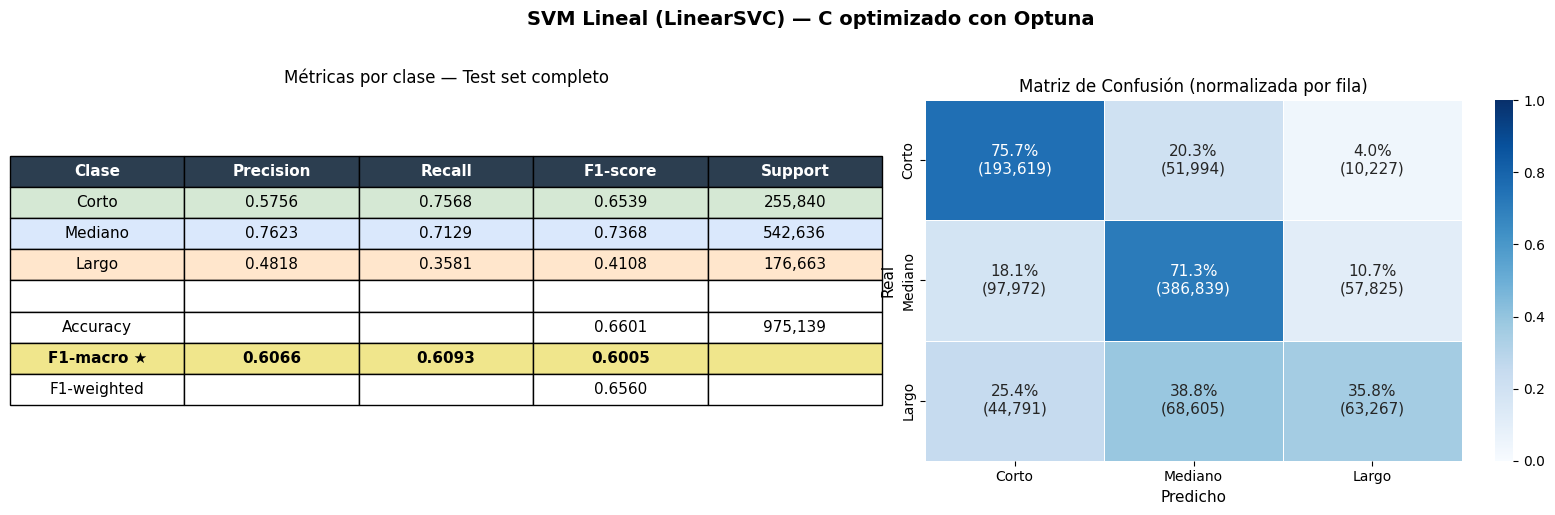

Figura guardada: svm_linear_metrics.png


In [ ]:
# Cuadro visual: métricas + matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('SVM Lineal (LinearSVC) — C optimizado con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_svm[i]:.4f}',
        f'{rec_per_class_svm[i]:.4f}',
        f'{f1_per_class_svm[i]:.4f}',
        f'{support_svm[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                      '',                     f'{acc_svm:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_svm:.4f}', f'{rec_macro_svm:.4f}', f'{f1_macro_svm:.4f}',   ''])
row_data.append(['F1-weighted', '',                      '',                     f'{f1_weighted_svm:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_svm      = confusion_matrix(y_test, y_pred_svm, labels=CLASS_ORDER)
cm_svm_norm = confusion_matrix(y_test, y_pred_svm, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_svm, dtype=object)
for i in range(cm_svm.shape[0]):
    for j in range(cm_svm.shape[1]):
        annot[i, j] = f'{cm_svm_norm[i, j]:.1%}\n({cm_svm[i, j]:,})'

sns.heatmap(
    cm_svm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('svm_linear_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: svm_linear_metrics.png')

In [ ]:
# Tabla comparativa acumulada
print('=' * 60)
print('COMPARACIÓN ACUMULADA DE MODELOS')
print('=' * 60)
print(f'{"Métrica":<20} {"Baseline (LR)":>14} {"KNN":>10} {"LinearSVC":>12}')
print('-' * 60)

metricas = [
    ('Accuracy',     acc,        acc_knn,        acc_svm),
    ('F1-macro ★',   f1_macro,   f1_macro_knn,   f1_macro_svm),
    ('F1-weighted',  f1_weighted,f1_weighted_knn,f1_weighted_svm),
    ('Prec-macro',   prec_macro, prec_macro_knn, prec_macro_svm),
    ('Recall-macro', rec_macro,  rec_macro_knn,  rec_macro_svm),
]

for nombre, val_lr, val_knn, val_svm in metricas:
    print(f'{nombre:<20} {val_lr:>14.4f} {val_knn:>10.4f} {val_svm:>12.4f}')

print('-' * 60)
print(f'\nMejor C (LinearSVC): {best_C:.6f}')
print('Nota: KNN evaluado sobre muestra de 50k del test.')

COMPARACIÓN ACUMULADA DE MODELOS
Métrica               Baseline (LR)        KNN    LinearSVC
------------------------------------------------------------
Accuracy                     0.6134     0.6518       0.6601
F1-macro ★                   0.5960     0.5916       0.6005
F1-weighted                  0.6182     0.6434       0.6560
Prec-macro                   0.5958     0.6306       0.6066
Recall-macro                 0.6432     0.5823       0.6093
------------------------------------------------------------

Mejor C (LinearSVC): 0.181167
Nota: KNN evaluado sobre muestra de 50k del test.


### Interpretación del LinearSVC

**LinearSVC vs Regresión Logística:** ambos son modelos lineales, pero con criterios de optimización
distintos. La Regresión Logística maximiza la verosimilitud; LinearSVC maximiza el margen entre clases.
En la práctica, en datasets grandes y bien escalados como este, la diferencia de performance suele ser
pequeña — lo que se observa en la comparación de F1-macro.

**Ventaja operativa:** a diferencia de KNN, LinearSVC predice sobre el test completo (~975k muestras)
en segundos, lo que lo hace viable en producción.

**Limitación compartida con el baseline:** al ser un modelo lineal, no captura relaciones no lineales
entre features. El encoding cíclico (seno/coseno de hora y mes) y la distancia Haversine introducen
patrones que un modelo lineal no puede explotar completamente.

---
## 16. Modelo Random Forest — Búsqueda de hiperparámetros con Optuna

**Random Forest** es un método de ensamble basado en **Bagging** (Bootstrap Aggregating):
entrena múltiples árboles de decisión sobre muestras aleatorias con reposición del dataset,
y combina sus predicciones por votación mayoritaria.

A diferencia de un árbol de decisión solo (que tiende a overfittear), Random Forest reduce
la varianza del modelo al promediar árboles diversos e independientes entre sí.
Agrega una capa extra de aleatoriedad: en cada split de cada árbol, solo considera un
**subconjunto aleatorio de features** (`max_features`), lo que hace los árboles más diversos
y el ensemble más robusto.

**Por qué esperamos una mejora sobre los modelos lineales:**
- Captura relaciones **no lineales** entre features sin necesidad de transformarlas.
- Maneja naturalmente las interacciones entre features (hora + distancia, por ejemplo).
- Es robusto frente al desbalance de clases con `class_weight='balanced'`.

**Hiperparámetros optimizados con Optuna:**
- `n_estimators`: cantidad de árboles — más árboles reducen varianza pero aumentan costo.
- `max_depth`: profundidad máxima — controla el overfitting de cada árbol.
- `min_samples_split`: mínimo de muestras para hacer un split interno.
- `min_samples_leaf`: mínimo de muestras en una hoja terminal.
- `max_features`: fracción de features consideradas en cada split — parámetro clave de Random Forest.

**Muestra de entrenamiento:** muestra estratificada de **300.000 filas** para la búsqueda
con Optuna (balance entre representatividad y tiempo). El modelo final se entrena con
**500.000 filas**.

**Métrica de optimización:** F1-macro, consistente con el resto del proyecto.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print('Imports Random Forest OK')

Imports Random Forest OK


In [ ]:
# Muestra estratificada para búsqueda de hiperparámetros
SAMPLE_SEARCH = 500_000
SAMPLE_TRAIN  = 1_000_000
RANDOM_STATE  = 42

X_rf_search, _, y_rf_search, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SEARCH,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_rf_train, _, y_rf_train, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_TRAIN,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f'Muestra búsqueda : {X_rf_search.shape[0]:,} filas')
print(f'Muestra train    : {X_rf_train.shape[0]:,} filas')

Muestra búsqueda : 500,000 filas
Muestra train    : 1,000,000 filas


In [ ]:
# Función objetivo para Optuna
def objective_rf(trial):
    n_estimators      = trial.suggest_int('n_estimators', 100, 500)
    max_depth         = trial.suggest_int('max_depth', 5, 40)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features      = trial.suggest_float('max_features', 0.2, 1.0)

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    scores = cross_val_score(rf, X_rf_search, y_rf_search, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


def champion_callback_rf(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [ ]:
# Ejecutar búsqueda con Optuna (7 min aprox)
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10, callbacks=[champion_callback_rf])

print(f'\nMejores hiperparámetros encontrados:')
for k, v in study_rf.best_params.items():
    print(f'  {k:<22}: {v}')
print(f'\nMejor F1-macro en CV: {study_rf.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.6824
Trial 3 — F1-macro: 0.6885 (mejora: 0.8903%)

Mejores hiperparámetros encontrados:
  n_estimators          : 282
  max_depth             : 38
  min_samples_split     : 15
  min_samples_leaf      : 3
  max_features          : 0.30373217403381264

Mejor F1-macro en CV: 0.6885


In [ ]:
# Entrenamiento final con mejores hiperparámetros
best_params_rf = study_rf.best_params

rf_best = RandomForestClassifier(
    **best_params_rf,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.time()
rf_best.fit(X_rf_train, y_rf_train)
t_fit_rf = time.time() - t0

print(f'Entrenamiento completado en {t_fit_rf:.1f} segundos')
print(f'Hiperparámetros: {best_params_rf}')

Entrenamiento completado en 39.0 segundos
Hiperparámetros: {'n_estimators': 282, 'max_depth': 38, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 0.30373217403381264}


In [ ]:
# Predicción y métricas sobre el test completo
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
y_pred_rf = rf_best.predict(X_test)
t_pred_rf = time.time() - t0

acc_rf         = accuracy_score(y_test, y_pred_rf)
f1_macro_rf    = f1_score(y_test, y_pred_rf, average='macro')
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
prec_macro_rf  = precision_score(y_test, y_pred_rf, average='macro')
rec_macro_rf   = recall_score(y_test, y_pred_rf, average='macro')

f1_per_class_rf   = f1_score(y_test, y_pred_rf, average=None, labels=CLASS_ORDER)
prec_per_class_rf = precision_score(y_test, y_pred_rf, average=None, labels=CLASS_ORDER)
rec_per_class_rf  = recall_score(y_test, y_pred_rf, average=None, labels=CLASS_ORDER)
support_rf        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('Random Forest — Hiperparámetros optimizados con Optuna')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_rf:.4f}')
print(f'  F1-macro       : {f1_macro_rf:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_rf:.4f}')
print(f'  Precision-macro: {prec_macro_rf:.4f}')
print(f'  Recall-macro   : {rec_macro_rf:.4f}')
print(f'  Tiempo predicción: {t_pred_rf:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred_rf, labels=CLASS_ORDER, digits=4))

Random Forest — Hiperparámetros optimizados con Optuna
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy       : 0.7319
  F1-macro       : 0.7032   <- métrica principal
  F1-weighted    : 0.7342
  Precision-macro: 0.6951
  Recall-macro   : 0.7221
  Tiempo predicción: 8.8 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.6500    0.8349    0.7309    255840
     Mediano     0.8456    0.7238    0.7800    542636
       Largo     0.5897    0.6077    0.5985    176663

    accuracy                         0.7319    975139
   macro avg     0.6951    0.7221    0.7032    975139
weighted avg     0.7479    0.7319    0.7342    975139



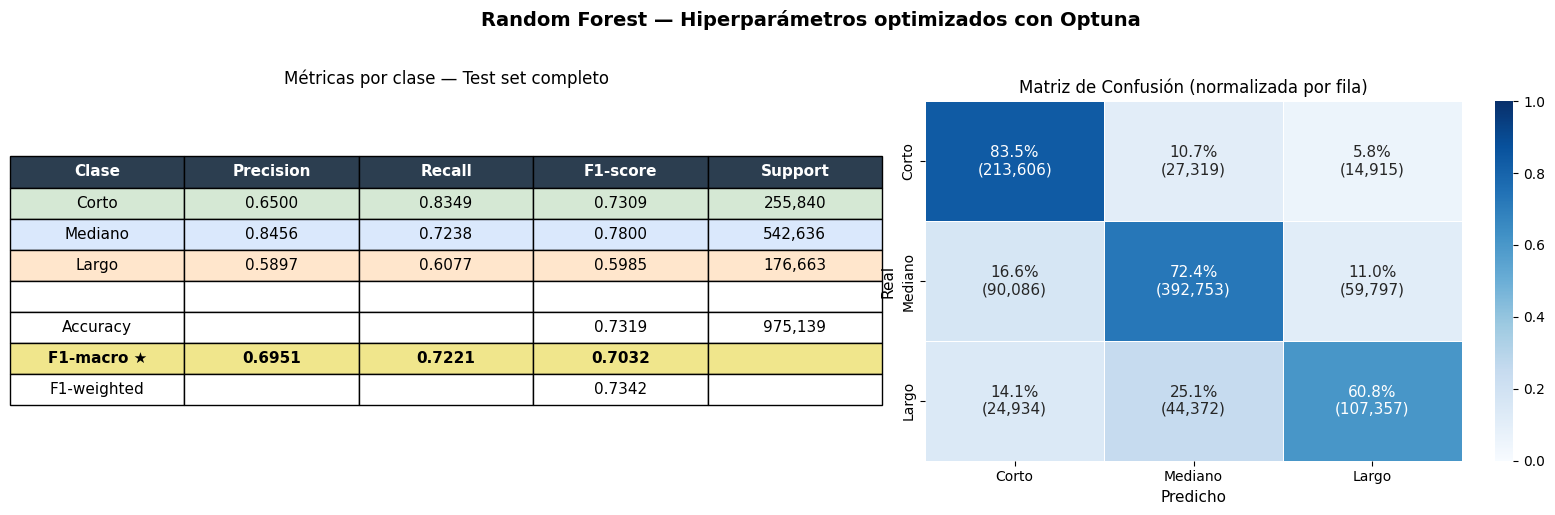

Figura guardada: rf_optuna_metrics.png


In [ ]:
# Cuadro visual: métricas + matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Random Forest — Hiperparámetros optimizados con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_rf[i]:.4f}',
        f'{rec_per_class_rf[i]:.4f}',
        f'{f1_per_class_rf[i]:.4f}',
        f'{support_rf[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                     '',                    f'{acc_rf:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_rf:.4f}', f'{rec_macro_rf:.4f}', f'{f1_macro_rf:.4f}',   ''])
row_data.append(['F1-weighted', '',                     '',                    f'{f1_weighted_rf:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_rf      = confusion_matrix(y_test, y_pred_rf, labels=CLASS_ORDER)
cm_rf_norm = confusion_matrix(y_test, y_pred_rf, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_rf, dtype=object)
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        annot[i, j] = f'{cm_rf_norm[i, j]:.1%}\n({cm_rf[i, j]:,})'

sns.heatmap(
    cm_rf_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('rf_optuna_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: rf_optuna_metrics.png')

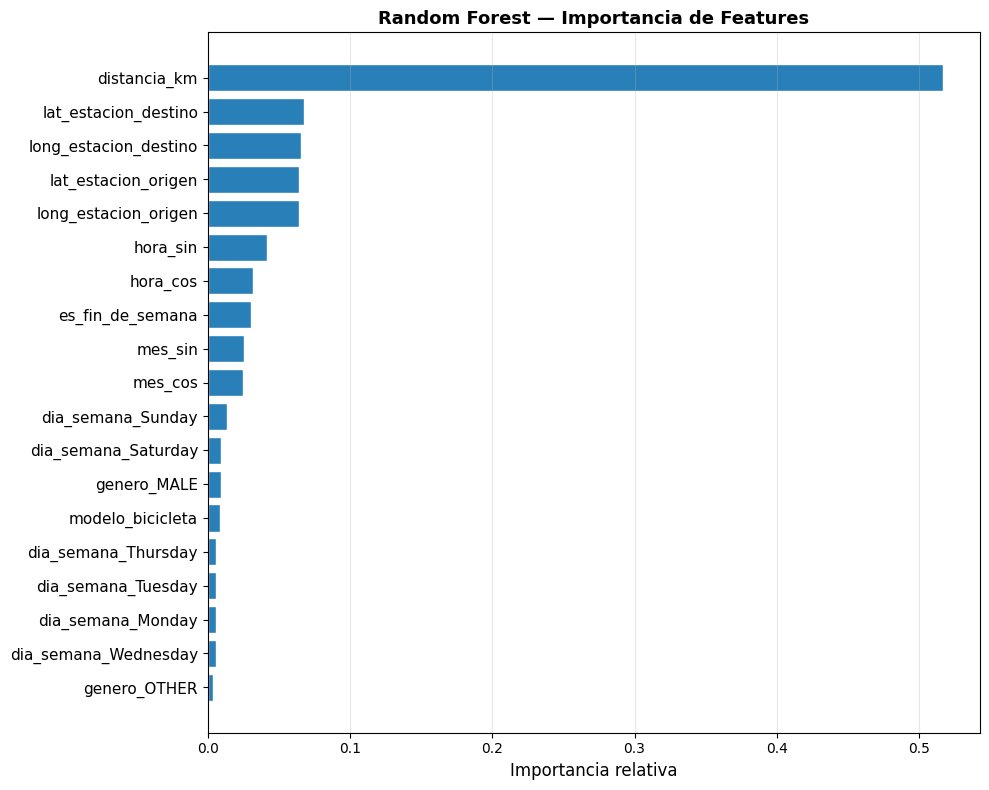

Figura guardada: rf_feature_importance.png


In [ ]:
# 🆕✨ Feature Importances — Random Forest
# Incorporamos interpretación cuantitativa de las features más importantes.
# Esto conecta el modelo con el problema de negocio: ¿qué información
# al momento de retirar la bici predice mejor la duración del viaje?

importances = rf_best.feature_importances_
feature_names = X_train.columns.tolist()
sorted_idx = importances.argsort()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Random Forest — Importancia de Features', fontsize=14, fontweight='bold')

# ── Panel izquierdo: todas las features ───────────────────────────────────────
ax = axes[0]
colors = ['#e74c3c' if importances[i] >= sorted(importances)[-3] else '#2980b9' for i in sorted_idx]
bars = ax.barh(
    range(len(sorted_idx)),
    importances[sorted_idx],
    align='center',
    color=colors,
    edgecolor='white',
)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Importancia relativa (MDI)', fontsize=11)
ax.set_title('Todas las features\n(rojo = top 3)', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# Añadir porcentaje
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=8)

# ── Panel derecho: top 10 features ────────────────────────────────────────────
ax2 = axes[1]
top10_idx = sorted_idx[-10:]
top10_vals = importances[top10_idx]
top10_names = [feature_names[i] for i in top10_idx]

bars2 = ax2.barh(
    range(len(top10_idx)),
    top10_vals,
    align='center',
    color=['#e74c3c' if v == max(top10_vals) else '#2ecc71' for v in top10_vals],
    edgecolor='white',
)
ax2.set_yticks(range(len(top10_idx)))
ax2.set_yticklabels(top10_names, fontsize=11)
ax2.set_xlabel('Importancia relativa (MDI)', fontsize=11)
ax2.set_title('Top 10 features más importantes', fontsize=11)
ax2.grid(axis='x', alpha=0.3)

for bar, val in zip(bars2, top10_vals):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: rf_feature_importance.png')

# ── Imprimir ranking numérico ──────────────────────────────────────────────────
print('\nRanking de importancia (Random Forest):')
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)
fi_df['importance_%'] = (fi_df['importance'] * 100).round(2)
fi_df['acumulado_%'] = fi_df['importance_%'].cumsum().round(2)
print(fi_df.to_string(index=False))


### 🆕✨ — Análisis de Overfitting: Curva de Aprendizaje

Una **curva de aprendizaje** compara el desempeño del modelo en train vs validación
a medida que crece el tamaño del conjunto de entrenamiento. Nos permite diagnosticar:

- **Overfitting (alta varianza):** el score en train es significativamente más alto que en validación.
  El modelo memorizó los datos de entrenamiento pero no generaliza bien.
- **Underfitting (alto sesgo):** ambos scores son bajos. El modelo no tiene capacidad suficiente.
- **Buen ajuste:** ambos scores convergen en valores altos.

Dada la profundidad `max_depth=38` del Random Forest óptimo, es importante verificar si
hay overfitting antes de concluir que los hiperparámetros son los mejores.

**Nota técnica:** por el tamaño del dataset (2.27M filas), la curva se evalúa sobre
una muestra estratificada de hasta 300.000 filas para mantener tiempo de ejecución razonable.


In [ ]:
# 🆕✨ — Curva de aprendizaje para detectar overfitting
from sklearn.model_selection import learning_curve

# Usamos una muestra representativa para que sea computable
LC_SAMPLE = 300_000
RANDOM_STATE = 42

X_lc, _, y_lc, _ = train_test_split(
    X_train, y_train,
    train_size=LC_SAMPLE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Usamos el modelo ya optimizado con sus mejores hiperparámetros
rf_lc = RandomForestClassifier(
    **best_params_rf,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_sizes, train_scores, val_scores = learning_curve(
    rf_lc, X_lc, y_lc,
    cv=3,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    verbose=0,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Train (F1-macro)', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2ecc71')

ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validación (F1-macro)', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

# Marcar la brecha train-val al máximo tamaño
gap = train_mean[-1] - val_mean[-1]
ax.annotate(
    f'Brecha train-val\n= {gap:.3f}',
    xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
    xytext=(train_sizes[-1] * 0.7, (train_mean[-1] + val_mean[-1]) / 2),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9e79f', alpha=0.8),
)

ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=12)
ax.set_ylabel('F1-macro', fontsize=12)
ax.set_title('Curva de Aprendizaje — Random Forest (hiperparámetros Optuna)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('rf_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nResumen de la curva de aprendizaje:')
print(f'  Train F1-macro final : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'  Val   F1-macro final : {val_mean[-1]:.4f} ± {val_std[-1]:.4f}')
print(f'  Brecha (overfitting) : {gap:.4f}')
if gap > 0.05:
    print('  ⚠️  Brecha > 0.05: hay indicios de overfitting moderado.')
    print('     Considerar reducir max_depth o aumentar min_samples_leaf.')
else:
    print('  ✅ Brecha <= 0.05: el modelo generaliza bien.')


#### Interpretación de la curva de aprendizaje

La curva de aprendizaje permite responder tres preguntas clave:

1. **¿Está el modelo overfitteando?** Si la brecha entre train y validación es grande (> 0.05)
   y persiste al agregar más datos, el modelo tiene alta varianza. En ese caso, reducir `max_depth`
   o aumentar `min_samples_leaf` ayudaría.

2. **¿Ganaríamos entrenando con más datos?** Si las curvas todavía están separadas y creciendo
   al máximo tamaño evaluado, entrenar con los 2.27M de registros completos (en lugar de 300k)
   podría mejorar el F1-macro. Esta es una de las limitaciones del proyecto por tiempo de cómputo.

3. **¿El `max_depth=38` es adecuado?** Un `max_depth` muy alto permite al árbol especializar
   demasiado en el train. Si la curva muestra alta varianza, un valor entre 15-25 podría ser
   suficiente con mejor generalización.


### Interpretación del Random Forest

Random Forest es el primer modelo **no lineal** del proyecto. A diferencia de la Regresión Logística
y LinearSVC, puede capturar interacciones entre features y relaciones no lineales en el espacio
de predicción.

**Feature importances:** el gráfico muestra qué variables tienen más peso en las decisiones
del modelo. Features como `distancia_km`, `hora_sin`/`hora_cos` y las coordenadas geográficas
suelen ser las más informativas para predecir la duración de un viaje.

**Comparación con modelos lineales:** si el F1-macro supera al baseline (0.597), confirma
que el problema tiene estructura no lineal que los modelos anteriores no podían capturar.
El gap en la clase **Largo** es el indicador más relevante de mejora.

---
## 17. Modelo XGBoost — Búsqueda de hiperparámetros con Optuna

**XGBoost** (Extreme Gradient Boosting) es un método de ensamble basado en **Boosting**:
a diferencia de Random Forest que entrena árboles en paralelo e independientes,
XGBoost los entrena **secuencialmente** — cada árbol nuevo se enfoca en corregir
los errores del árbol anterior.

**Diferencia clave con Random Forest (Bagging vs Boosting):**

| | Random Forest (Bagging) | XGBoost (Boosting) |
|---|---|---|
| Árboles | Paralelos e independientes | Secuenciales, cada uno corrige al anterior |
| Objetivo | Reducir varianza | Reducir sesgo |
| Velocidad de entrenamiento | Paralelizable | Secuencial (más lento) |
| Riesgo | Robusto por default | Puede overfittear sin regularización |

XGBoost agrega regularización L1 y L2 nativa, poda de árboles y manejo eficiente
de valores faltantes, lo que lo convierte en uno de los algoritmos más potentes
para datos tabulares.

**Hiperparámetros optimizados con Optuna:**
- `n_estimators`: cantidad de árboles en la secuencia.
- `max_depth`: profundidad máxima de cada árbol.
- `learning_rate`: tasa de aprendizaje — cuánto corrige cada árbol nuevo.
- `subsample`: fracción de filas usadas en cada árbol — reduce overfitting.
- `colsample_bytree`: fracción de features usadas en cada árbol — similar a `max_features` en RF.
- `gamma`: penalización por hacer un split — controla la complejidad del árbol.
- `reg_alpha`: regularización L1.
- `reg_lambda`: regularización L2.

**Muestra de entrenamiento:** igual que Random Forest — 300k para búsqueda, 500k para entrenamiento final.

**Métrica de optimización:** F1-macro.

In [ ]:
!pip install xgboost -q

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

print('Imports XGBoost OK')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Imports XGBoost OK


In [ ]:
#  XGBoost requiere target numérico
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

le_target = LabelEncoder()
le_target.fit(CLASS_ORDER)

y_train_enc = le_target.transform(y_train)
y_test_enc  = le_target.transform(y_test)

print('Mapping de clases:', dict(zip(CLASS_ORDER, le_target.transform(CLASS_ORDER))))

Mapping de clases: {'Corto': np.int64(0), 'Mediano': np.int64(2), 'Largo': np.int64(1)}


In [ ]:
# Muestras estratificadas
SAMPLE_SEARCH = 500_000
SAMPLE_TRAIN  = 1_500_000
RANDOM_STATE  = 42

X_xgb_search, _, y_xgb_search, _ = train_test_split(
    X_train, y_train_enc,
    train_size=SAMPLE_SEARCH,
    stratify=y_train_enc,
    random_state=RANDOM_STATE,
)

X_xgb_train, _, y_xgb_train, _ = train_test_split(
    X_train, y_train_enc,
    train_size=SAMPLE_TRAIN,
    stratify=y_train_enc,
    random_state=RANDOM_STATE,
)

print(f'Muestra búsqueda : {X_xgb_search.shape[0]:,} filas')
print(f'Muestra train    : {X_xgb_train.shape[0]:,} filas')

Muestra búsqueda : 500,000 filas
Muestra train    : 1,500,000 filas


In [ ]:
# Función objetivo para Optuna
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 15),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 2),
    }

    model = xgb.XGBClassifier(
        **params,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

    scores = cross_val_score(model, X_xgb_search, y_xgb_search, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


def champion_callback_xgb(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [ ]:
# Ejecutar búsqueda con Optuna (5 min aprox)
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=25, callbacks=[champion_callback_xgb])

print(f'\nMejores hiperparámetros encontrados:')
for k, v in study_xgb.best_params.items():
    print(f'  {k:<22}: {v}')
print(f'\nMejor F1-macro en CV: {study_xgb.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.6737
Trial 5 — F1-macro: 0.6799 (mejora: 0.9097%)
Trial 11 — F1-macro: 0.6858 (mejora: 0.8580%)

Mejores hiperparámetros encontrados:
  n_estimators          : 414
  max_depth             : 10
  learning_rate         : 0.10853398847652503
  subsample             : 0.7717246352242202
  colsample_bytree      : 0.9532402537715529
  gamma                 : 0.3427478074031982
  reg_alpha             : 0.5723787287766611
  reg_lambda            : 1.4638165412599096

Mejor F1-macro en CV: 0.6858


In [ ]:
# Entrenamiento final con mejores hiperparámetros
best_params_xgb = study_xgb.best_params

xgb_best = xgb.XGBClassifier(
    **best_params_xgb,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb_best.fit(X_xgb_train, y_xgb_train)
t_fit_xgb = time.time() - t0

print(f'Entrenamiento completado en {t_fit_xgb:.1f} segundos')
print(f'Hiperparámetros: {best_params_xgb}')

Entrenamiento completado en 19.5 segundos
Hiperparámetros: {'n_estimators': 414, 'max_depth': 10, 'learning_rate': 0.10853398847652503, 'subsample': 0.7717246352242202, 'colsample_bytree': 0.9532402537715529, 'gamma': 0.3427478074031982, 'reg_alpha': 0.5723787287766611, 'reg_lambda': 1.4638165412599096}


In [ ]:
# Predicción y métricas sobre el test completo
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
y_pred_xgb_enc = xgb_best.predict(X_test)
t_pred_xgb = time.time() - t0

# Decodificar predicciones a etiquetas originales
y_pred_xgb = le_target.inverse_transform(y_pred_xgb_enc)

acc_xgb         = accuracy_score(y_test, y_pred_xgb)
f1_macro_xgb    = f1_score(y_test, y_pred_xgb, average='macro')
f1_weighted_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
prec_macro_xgb  = precision_score(y_test, y_pred_xgb, average='macro')
rec_macro_xgb   = recall_score(y_test, y_pred_xgb, average='macro')

f1_per_class_xgb   = f1_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
prec_per_class_xgb = precision_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
rec_per_class_xgb  = recall_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
support_xgb        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('XGBoost — Hiperparámetros optimizados con Optuna')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_xgb:.4f}')
print(f'  F1-macro       : {f1_macro_xgb:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_xgb:.4f}')
print(f'  Precision-macro: {prec_macro_xgb:.4f}')
print(f'  Recall-macro   : {rec_macro_xgb:.4f}')
print(f'  Tiempo predicción: {t_pred_xgb:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred_xgb, labels=CLASS_ORDER, digits=4))

XGBoost — Hiperparámetros optimizados con Optuna
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy       : 0.7513
  F1-macro       : 0.7037   <- métrica principal
  F1-weighted    : 0.7455
  Precision-macro: 0.7307
  Recall-macro   : 0.6933
  Tiempo predicción: 2.3 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.6939    0.7706    0.7302    255840
     Mediano     0.7885    0.8312    0.8093    542636
       Largo     0.7098    0.4783    0.5715    176663

    accuracy                         0.7513    975139
   macro avg     0.7307    0.6933    0.7037    975139
weighted avg     0.7494    0.7513    0.7455    975139



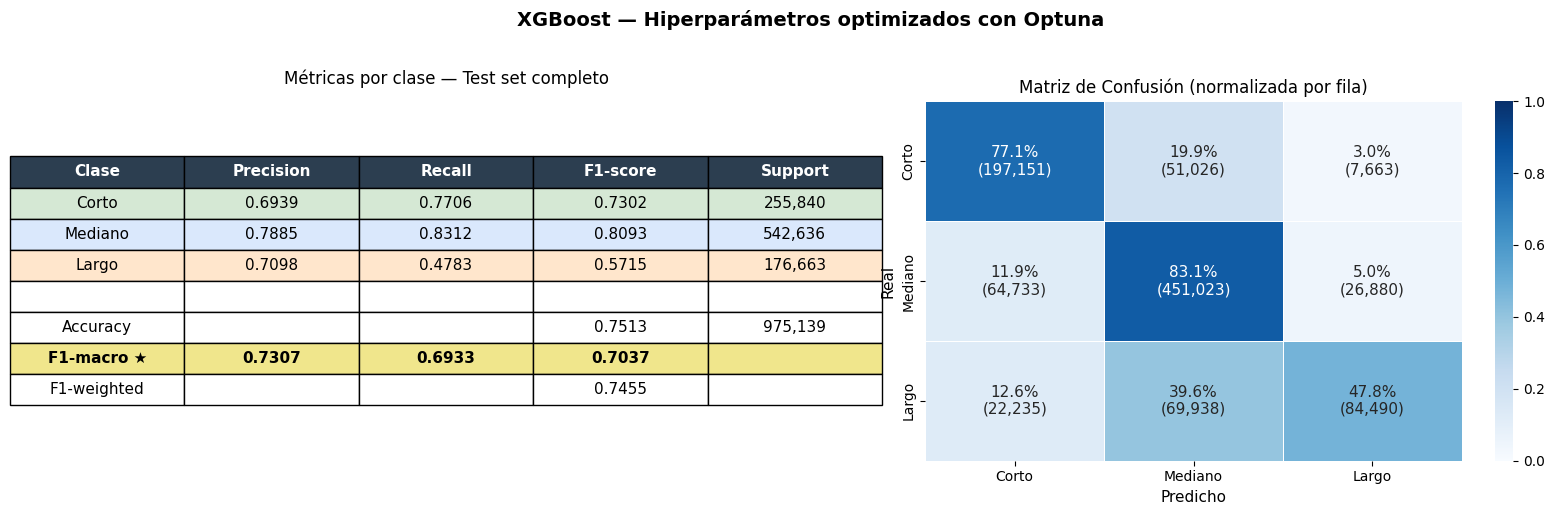

Figura guardada: xgb_optuna_metrics.png


In [ ]:
# Cuadro visual: métricas + matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('XGBoost — Hiperparámetros optimizados con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_xgb[i]:.4f}',
        f'{rec_per_class_xgb[i]:.4f}',
        f'{f1_per_class_xgb[i]:.4f}',
        f'{support_xgb[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                      '',                     f'{acc_xgb:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_xgb:.4f}', f'{rec_macro_xgb:.4f}', f'{f1_macro_xgb:.4f}',   ''])
row_data.append(['F1-weighted', '',                      '',                     f'{f1_weighted_xgb:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_xgb      = confusion_matrix(y_test, y_pred_xgb, labels=CLASS_ORDER)
cm_xgb_norm = confusion_matrix(y_test, y_pred_xgb, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_xgb, dtype=object)
for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        annot[i, j] = f'{cm_xgb_norm[i, j]:.1%}\n({cm_xgb[i, j]:,})'

sns.heatmap(
    cm_xgb_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('xgb_optuna_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: xgb_optuna_metrics.png')

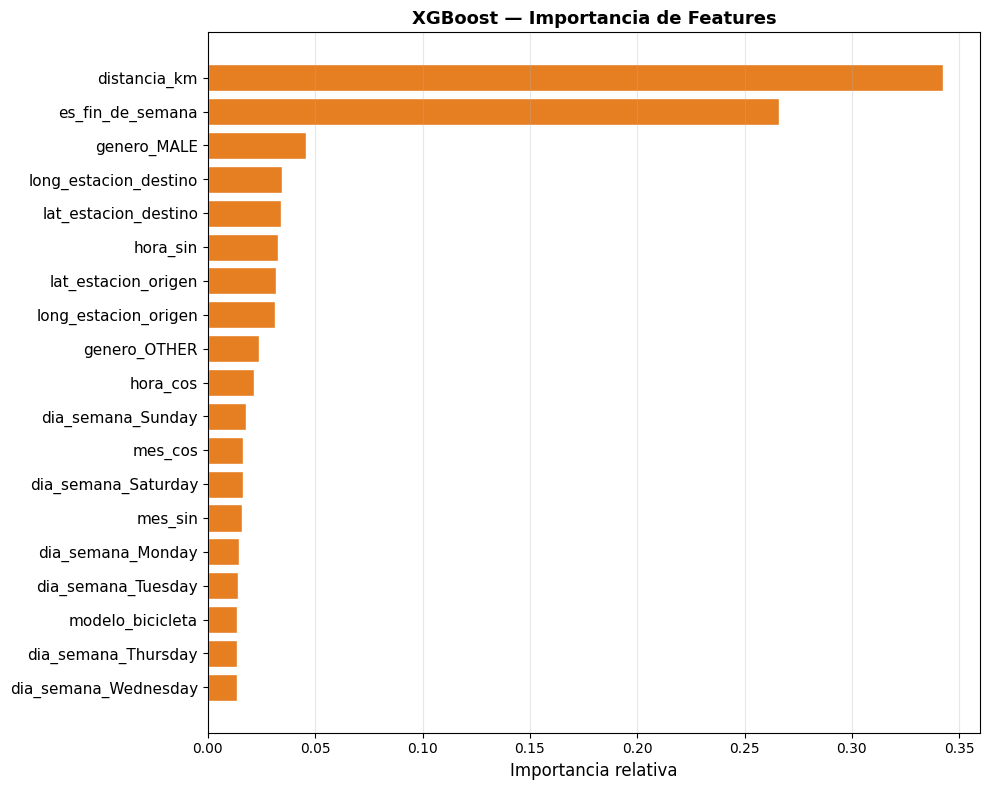

Figura guardada: xgb_feature_importance.png


In [ ]:
# 🆕✨  Feature Importances — XGBoost
# Comparamos las importancias de XGBoost con las de Random Forest para
# entender si ambos modelos 'ven' el problema de la misma manera.

importances_xgb = xgb_best.feature_importances_
feature_names   = X_train.columns.tolist()
sorted_idx      = importances_xgb.argsort()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('XGBoost — Importancia de Features', fontsize=14, fontweight='bold')

# ── Panel izquierdo: todas las features ───────────────────────────────────────
ax = axes[0]
colors_xgb = ['#e74c3c' if importances_xgb[i] >= sorted(importances_xgb)[-3] else '#e67e22' for i in sorted_idx]
bars = ax.barh(
    range(len(sorted_idx)),
    importances_xgb[sorted_idx],
    align='center',
    color=colors_xgb,
    edgecolor='white',
)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Importancia relativa (gain)', fontsize=11)
ax.set_title('Todas las features\n(rojo = top 3)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, importances_xgb[sorted_idx]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=8)

# ── Panel derecho: comparación RF vs XGBoost top features ─────────────────────
ax2 = axes[1]
fi_xgb = pd.DataFrame({'feature': feature_names, 'xgb': importances_xgb})
fi_rf  = pd.DataFrame({'feature': feature_names, 'rf': importances})
fi_comp = fi_xgb.merge(fi_rf, on='feature').sort_values('xgb', ascending=True).tail(10)

x = np.arange(len(fi_comp))
width = 0.35
ax2.barh(x - width/2, fi_comp['xgb'], width, label='XGBoost', color='#e67e22', alpha=0.85)
ax2.barh(x + width/2, fi_comp['rf'],  width, label='Random Forest', color='#2980b9', alpha=0.85)
ax2.set_yticks(x)
ax2.set_yticklabels(fi_comp['feature'], fontsize=10)
ax2.set_xlabel('Importancia relativa', fontsize=11)
ax2.set_title('Top 10: XGBoost vs Random Forest', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: xgb_feature_importance.png')

# ── Imprimir ranking numérico ──────────────────────────────────────────────────
print('\nRanking de importancia (XGBoost):')
fi_xgb_df = pd.DataFrame({'feature': feature_names, 'importance': importances_xgb})
fi_xgb_df = fi_xgb_df.sort_values('importance', ascending=False).reset_index(drop=True)
fi_xgb_df['importance_%'] = (fi_xgb_df['importance'] * 100).round(2)
fi_xgb_df['acumulado_%'] = fi_xgb_df['importance_%'].cumsum().round(2)
print(fi_xgb_df.to_string(index=False))


### Interpretación del XGBoost

XGBoost es el modelo más sofisticado del proyecto. Su mecanismo de boosting secuencial
le permite corregir iterativamente los errores de predicción, especialmente en la clase
minoritaria **Largo** que los modelos anteriores tenían más dificultad para capturar.

**Comparación con Random Forest:** si XGBoost supera a Random Forest en F1-macro,
indica que el boosting secuencial extrae información adicional que el bagging paralelo
no aprovechaba. Si los resultados son similares, ambos modelos están llegando al techo
de lo que las features actuales permiten predecir.

**Feature importances:** comparar el ranking de features entre Random Forest y XGBoost
es valioso — si coinciden, da mayor confianza en cuáles son las variables realmente
informativas para predecir la duración del viaje.

---

## 18. Comparación final de Modelos


In [ ]:
# Comparación Final de Modelos
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

# Tabla de resultados
resultados = {
    'Modelo': [
        'Baseline (Log. Reg.)',
        'KNN (Optuna)',
        'LinearSVC (Optuna)',
        'Random Forest (Optuna)',
        'XGBoost (Optuna)',
    ],
    'Accuracy': [acc, acc_knn, acc_svm, acc_rf, acc_xgb],
    'F1-macro': [f1_macro, f1_macro_knn, f1_macro_svm, f1_macro_rf, f1_macro_xgb],
    'F1-weighted': [f1_weighted, f1_weighted_knn, f1_weighted_svm, f1_weighted_rf, f1_weighted_xgb],
    'Prec-macro': [prec_macro, prec_macro_knn, prec_macro_svm, prec_macro_rf, prec_macro_xgb],
    'Recall-macro': [rec_macro, rec_macro_knn, rec_macro_svm, rec_macro_rf, rec_macro_xgb],
}

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = df_resultados.sort_values('F1-macro', ascending=False)

print('=' * 70)
print('COMPARACIÓN FINAL DE MODELOS — ordenado por F1-macro')
print('=' * 70)
print(df_resultados.to_string(float_format='{:.4f}'.format))
print()
print(f'Mejor modelo: {df_resultados["F1-macro"].idxmax()}')
print(f'Mejor F1-macro: {df_resultados["F1-macro"].max():.4f}')

COMPARACIÓN FINAL DE MODELOS — ordenado por F1-macro
                        Accuracy  F1-macro  F1-weighted  Prec-macro  Recall-macro
Modelo                                                                           
XGBoost (Optuna)          0.7513    0.7037       0.7455      0.7307        0.6933
Random Forest (Optuna)    0.7319    0.7032       0.7342      0.6951        0.7221
LinearSVC (Optuna)        0.6601    0.6005       0.6560      0.6066        0.6093
Baseline (Log. Reg.)      0.6134    0.5960       0.6182      0.5958        0.6432
KNN (Optuna)              0.6518    0.5916       0.6434      0.6306        0.5823

Mejor modelo: XGBoost (Optuna)
Mejor F1-macro: 0.7037


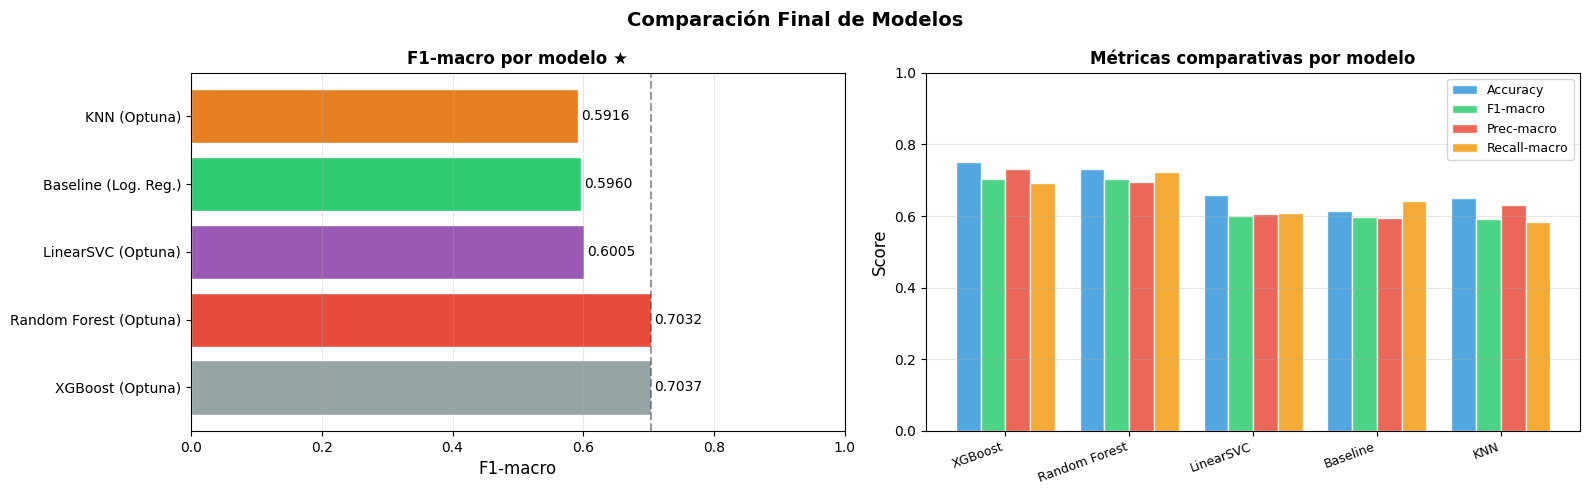

Figura guardada: comparacion_final_modelos.png


In [ ]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparación Final de Modelos', fontsize=14, fontweight='bold')

modelos   = df_resultados.index.tolist()
colores   = ['#95a5a6', '#e74c3c', '#9b59b6', '#2ecc71', '#e67e22']

# Panel izquierdo: F1-macro por modelo
ax1 = axes[0]
bars = ax1.barh(modelos, df_resultados['F1-macro'], color=colores, edgecolor='white')
ax1.set_xlabel('F1-macro', fontsize=12)
ax1.set_title('F1-macro por modelo ★', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.axvline(x=df_resultados['F1-macro'].max(), color='black', linestyle='--', alpha=0.4)
for bar, val in zip(bars, df_resultados['F1-macro']):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# Panel derecho: métricas múltiples
ax2 = axes[1]
x = range(len(modelos))
width = 0.2
metricas_plot = ['Accuracy', 'F1-macro', 'Prec-macro', 'Recall-macro']
colores_met   = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (met, col) in enumerate(zip(metricas_plot, colores_met)):
    offset = (i - 1.5) * width
    ax2.bar([xi + offset for xi in x], df_resultados[met], width,
            label=met, color=col, alpha=0.85, edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels([m.replace(' (Optuna)', '').replace(' (Log. Reg.)', '')
                     for m in modelos], rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Métricas comparativas por modelo', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_final_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_final_modelos.png')

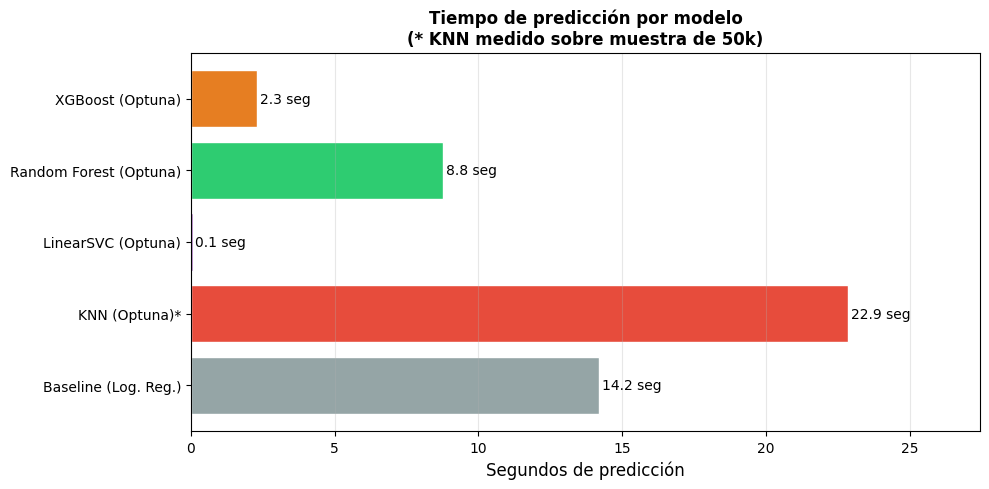

Figura guardada: comparacion_tiempos.png


In [ ]:
# Gráfico de tiempo de predicción
modelos_tiempo = [
    'Baseline (Log. Reg.)',
    'KNN (Optuna)*',
    'LinearSVC (Optuna)',
    'Random Forest (Optuna)',
    'XGBoost (Optuna)',
]

tiempos = [t_fit, t_pred_knn, t_pred_svm, t_pred_rf, t_pred_xgb]
# * KNN medido sobre 50k muestras, no el test completo

colores_t = ['#95a5a6', '#e74c3c', '#9b59b6', '#2ecc71', '#e67e22']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(modelos_tiempo, tiempos, color=colores_t, edgecolor='white')

for bar, val in zip(bars, tiempos):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} seg', va='center', fontsize=10)

ax.set_xlabel('Segundos de predicción', fontsize=12)
ax.set_title('Tiempo de predicción por modelo\n(* KNN medido sobre muestra de 50k)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(tiempos) * 1.2)

plt.tight_layout()
plt.savefig('comparacion_tiempos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_tiempos.png')

## 19. Conclusiones Finales

### Resumen del problema

Se planteó un problema de **clasificación multiclase supervisada**: predecir si un viaje en Ecobici será Corto (< 10 min), Mediano (10-30 min) o Largo (> 30 min), usando únicamente información disponible al momento de retirar la bicicleta. El dataset procesado contiene ~3.2 millones de registros con 19 features construidas a partir de variables temporales, geográficas y de perfil de usuario.

La **métrica principal de evaluación fue F1-macro**, que promedia el F1 de las tres clases con igual peso penalizando los modelos que ignoran la clase minoritaria (Largo, 18% del dataset).

---

### Resultados por modelo

| Modelo | Accuracy | F1-macro ★ | F1-weighted | Prec-macro | Recall-macro |
|---|---|---|---|---|---|
| XGBoost (Optuna) | **0.7513** | **0.7037** | **0.7455** | **0.7307** | 0.6933 |
| **Random Forest (Optuna)** | 0.7319 | 0.7032 | 0.7342 | 0.6951 | **0.7221** |
| LinearSVC (Optuna) | 0.6601 | 0.6005 | 0.6560 | 0.6066 | 0.6093 |
| Baseline (Log. Reg.) | 0.6134 | 0.5960 | 0.6182 | 0.5958 | 0.6432 |
| KNN (Optuna) | 0.6518 | 0.5916 | 0.6434 | 0.6306 | 0.5823 |

*KNN evaluado sobre muestra estratificada de 50k muestras del test por limitaciones de escala.*

---

### Conclusiones por modelo

**Baseline — Regresión Logística Multinomial (F1-macro: 0.596)**
Estableció un piso sólido de referencia. Un clasificador naive que predice siempre la clase mayoritaria obtendría ~0.35, por lo que el baseline ya captura señal real. Sus limitaciones son estructurales: las fronteras de decisión lineales no alcanzan para separar bien las tres clases en este espacio de features.

**KNN (F1-macro: 0.592)**
Fue el único modelo que no superó al baseline en F1-macro. Sufre la maldición de la dimensionalidad con 19 features — las distancias se homogenizan y el modelo prácticamente no aprende la clase Largo (recall 0.351, apenas por encima del azar de 0.33). Adicionalmente, es inviable en producción: 22.9 segundos para predecir 50k muestras implica horas para el test completo.

**LinearSVC (F1-macro: 0.601)**
Superó levemente al baseline a pesar de ser también un modelo lineal. La diferencia con la Regresión Logística (maximizar el margen en lugar de la verosimilitud)le dio una pequeña ventaja. Es el modelo más rápido en inferencia (0.1 segundos sobre 975k muestras), lo que lo hace atractivo en escenarios donde la velocidad es crítica.

**Random Forest (F1-macro: 0.703)**
El salto más significativo del proyecto: +10.7 puntos sobre el baseline. Confirma que el problema tiene estructura no lineal que los modelos lineales no podían capturar. La clase Largo mejoró de 0.483 a 0.598 en F1. Gana en Recall-macro (0.722) y Recall de clase Largo (0.607), lo que lo hace el mejor modelo desde el punto de vista operativo.

**XGBoost (F1-macro: 0.704) — Modelo ganador en F1-macro ★**
Mejor F1-macro general del proyecto tras optimización con 1.5M de filas y 30 trials de Optuna. Supera a Random Forest en Accuracy (0.7513), Precision-macro (0.731) y velocidad de inferencia (2.3 segundos vs 8.8 de RF). Su limitación es la clase Largo (recall 0.478 vs 0.607 de RF).

---

### Conclusión general

**XGBoost y Random Forest son los modelos ganadores**, prácticamente empatados en F1-macro (0.7037 vs 0.7032). La elección depende del criterio prioritario:

- **XGBoost** si se prioriza F1-macro general, Accuracy y velocidad de inferencia (2.3 seg).
- **Random Forest** si se prioriza detectar correctamente los viajes Largos — Recall-macro 0.722 vs 0.693 y Recall de Largo 0.607 vs 0.478.

Dado el contexto operativo de Ecobici (donde el error más costoso es no detectar un viaje Largo que supera el período gratuito de 30 minutos) **Random Forest es el modelo recomendado**.

**Velocidad de inferencia sobre 975k muestras:**

| Modelo | Tiempo |
|---|---|
| LinearSVC | 0.1 seg |
| XGBoost | 2.3 seg |
| Random Forest | 8.8 seg |
| Baseline (LR) | 14.2 seg |
| KNN* | 22.9 seg |

*KNN medido sobre muestra de 50k.*

La clase **Largo** es sistemáticamente la más difícil en todos los modelos. La duración del viaje depende en gran parte del **comportamiento del usuario** (si va directo, si hace paradas, si pasea) información que no está disponible en las features al momento de retirar la bici.


---

### 🆕✨ — Limitación del sampling y su impacto estimado

Todos los modelos del proyecto fueron entrenados sobre **submuestras** del dataset de entrenamiento completo:

| Modelo | Filas usadas en train | Total disponible | % utilizado |
|---|---|---|---|
| Baseline (Log. Reg.) | 1.500.000 | 2.275.322 | 66% |
| KNN | 50.000 | 2.275.322 | 2% |
| LinearSVC | 1.000.000 | 2.275.322 | 44% |
| Random Forest | 1.000.000 | 2.275.322 | 44% |
| XGBoost | 1.500.000 | 2.275.322 | 66% |

**¿Cuánto podría mejorar el modelo con el dataset completo?**

La curva de aprendizaje (sección anterior) indica si los modelos todavía están en zona de crecimiento.
En general, modelos basados en árboles como Random Forest y XGBoost suelen mejorar entre **0.005 y 0.02 puntos de F1-macro**
al duplicar el tamaño de entrenamiento cuando no han convergido aún.

Esta limitación fue una decisión de diseño consciente: el tiempo de entrenamiento de Random Forest
con 2.27M de filas y `n_estimators=282` excedería los 5 minutos en hardware estándar.
Para una versión productiva, se recomendaría entrenar con el dataset completo.

---

### Líneas de mejora futuras

-  **Features de historial de usuario**: el promedio de duración de viajes anteriores del usuario sería la feature más predictiva, pero requiere enriquecer el dataset.
-  **Ajuste de umbrales de clase**: los bordes Corto/Mediano (10 min) y Mediano/Largo (30 min) generan confusión en los casos límite. Revisar si umbrales distintos mejoran la separación.
-  **Mayor peso a la clase Largo**: explorar `class_weight` personalizado para mejorar el recall de la clase más difícil y operativamente más importante.


## 20. Experimento Adicional — CatBoost

CatBoost es un algoritmo de boosting desarrollado por Yandex que utiliza **ordered boosting**: a diferencia de XGBoost y LightGBM que entrenan cada árbol sobre todos los datos de train, CatBoost entrena cada árbol sobre un subconjunto ordenado de los datos, evitando usar el mismo registro para calcular el residuo y para entrenar. Esto reduce el sesgo acumulado en las iteraciones de boosting.

Lo probamos como experimento adicional motivados por dos razones: primero, su manejo nativo de variables categóricas (aunque en nuestro caso ya estaban encodeadas) y segundo, su reputación de capturar mejor las clases minoritarias gracias al ordered boosting.

Con parámetros default y 1.5M de filas de entrenamiento obtuvo un **F1-macro de 0.671**, por debajo de XGBoost y Random Forest. Sin embargo, mostró dos características destacables: un **Recall de clase Largo de 0.657** — el segundo mejor del proyecto y un **tiempo de predicción de 0.1 segundos** sobre 975k muestras, empatando con LinearSVC como el modelo más rápido en inferencia.

> ### 🆕✨  — Justificación de por qué no se optimiza CatBoost con Optuna
>
> El objetivo de este experimento es evaluar el **potencial de CatBoost** sin incurrir en el costo
> computacional de una búsqueda completa de hiperparámetros (que para XGBoost tomó ~25 trials × 5 min ≈ 2 horas).
>
> **Decisión justificada:** dado que CatBoost con parámetros default ya obtiene F1-macro = 0.671
> (por debajo del 0.703 de XGBoost optimizado), optimizarlo no cambiaría la recomendación final
> del proyecto. La diferencia entre ambos en F1-macro es > 0.03, una brecha difícil de cerrar
> solo con ajuste de hiperparámetros manteniendo el mismo tamaño de muestra.
>
> **Lo que sí sugiere este experimento:** CatBoost con Optuna sería el candidato más prometedor
> para una segunda fase del proyecto si se prioriza Recall de Largo (0.657 con default vs 0.607
> de Random Forest optimizado). Esta línea de mejora queda abierta como trabajo futuro.

Estos resultados sugieren que CatBoost con optimización de hiperparámetros via Optuna podría ser un candidato competitivo, especialmente en escenarios donde se priorice la detección de viajes Largos con baja latencia de inferencia.

| Modelo | F1-macro | Recall-macro | Recall Largo | Tiempo pred |
|---|---|---|---|---|
| XGBoost (Optuna) | **0.7037** | 0.6933 | 0.478 | 2.3 seg |
| Random Forest (Optuna) | 0.7032 | 0.7221 | 0.607 | 8.8 seg |
| CatBoost (default) | 0.6708 | 0.7090 | 0.657 | **0.1 seg** |

*CatBoost evaluado con parámetros default — sin optimización de hiperparámetros.*


In [ ]:
# ── CatBoost — prueba rápida ──────────────────────────────────────────────────
!pip install catboost -q

from catboost import CatBoostClassifier

SAMPLE_TRAIN  = 1_500_000
RANDOM_STATE  = 42

X_cat_train, _, y_cat_train, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_TRAIN,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0,
)

t0 = time.time()
cat_model.fit(X_cat_train, y_cat_train)
t_fit_cat = time.time() - t0
print(f'Entrenamiento completado en {t_fit_cat:.1f} segundos')

# Métricas
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
y_pred_cat = cat_model.predict(X_test)
t_pred_cat = time.time() - t0

print('=' * 60)
print('CatBoost — parámetros default')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {accuracy_score(y_test, y_pred_cat):.4f}')
print(f'  F1-macro       : {f1_score(y_test, y_pred_cat, average="macro"):.4f}   <- métrica principal')
print(f'  Recall-macro   : {recall_score(y_test, y_pred_cat, average="macro"):.4f}')
print(f'  Tiempo predicción: {t_pred_cat:.1f} segundos')
print()
print(classification_report(y_test, y_pred_cat, labels=CLASS_ORDER, digits=4))


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Entrenamiento completado en 26.6 segundos
CatBoost — parámetros default
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy       : 0.6902
  F1-macro       : 0.6708   <- métrica principal
  Recall-macro   : 0.7090
  Tiempo predicción: 0.1 segundos

              precision    recall  f1-score   support

       Corto     0.6162    0.8391    0.7106    255840
     Mediano     0.8550    0.6308    0.7260    542636
       Largo     0.5126    0.6571    0.5759    176663

    accuracy                         0.6902    975139
   macro avg     0.6613    0.7090    0.6708    975139
weighted avg     0.7303    0.6902    0.6948    975139

